In [1]:
import os
import sys
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
plt.style.use('ggplot')
np.random.seed(1234)

np.set_printoptions(formatter={'all':lambda x: '%.3f' % x})

In [2]:
from IPython.display import Image
from scipy.optimize import minimize
from scipy.stats import bernoulli, binom

In [3]:
def neg_loglik(thetas, n, xs, zs):
    return -np.sum([binom(n, thetas[z]).logpmf(x) for (x, z) in zip(xs, zs)])


In [4]:
from scipy.stats import multivariate_normal as mvn

In [5]:
def em_gmm_orig(xs, pis, mus, sigmas, tol=0.01, max_iter=10000):

    n, p = xs.shape
    k = len(pis)

    ll_old = 0
    for i in range(max_iter):
        exp_A = []
        exp_B = []
        ll_new = 0

        # E-step
        ws = np.zeros((k, n))
        for j in range(len(mus)):
            for i in range(n):
                ws[j, i] = pis[j] * mvn(mus[j], sigmas[j]).pdf(xs[i])
        ws /= ws.sum(0)

        # M-step
        pis = np.zeros(k)
        for j in range(len(mus)):
            for i in range(n):
                pis[j] += ws[j, i]
        pis /= n

        mus = np.zeros((k, p))
        for j in range(k):
            for i in range(n):
                mus[j] += ws[j, i] * xs[i]
            mus[j] /= ws[j, :].sum()

        sigmas = np.zeros((k, p, p))
        for j in range(k):
            for i in range(n):
                ys = np.reshape(xs[i]- mus[j], (2,1))
                sigmas[j] += ws[j, i] * np.dot(ys, ys.T)
            sigmas[j] /= ws[j,:].sum()

        # update complete log likelihoood
        ll_new = 0.0
        for i in range(n):
            s = 0
            for j in range(k):
                s += pis[j] * mvn(mus[j], sigmas[j]).pdf(xs[i])
            ll_new += np.log(s)

        if np.abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new

    return ll_new, pis, mus, sigmas

In [8]:
def em_gmm_vect(xs, pis, mus, sigmas, tol=0.01, max_iter=100):

    n, p = xs.shape
    k = len(pis)

    ll_old = 0
    for i in range(max_iter):
        exp_A = []
        exp_B = []
        ll_new = 0

        # E-step
        ws = np.zeros((k, n))
        for j in range(k):
            ws[j, :] = pis[j] * mvn(mus[j], sigmas[j]).pdf(xs)
        ws /= ws.sum(0)

        # M-step
        pis = ws.sum(axis=1)
        pis /= n

        mus = np.dot(ws, xs)
        mus /= ws.sum(1)[:, None]

        sigmas = np.zeros((k, p, p))
        for j in range(k):
            ys = xs - mus[j, :]
            sigmas[j] = (ws[j,:,None,None] * mm(ys[:,:,None], ys[:,None,:])).sum(axis=0)
        sigmas /= ws.sum(axis=1)[:,None,None]

        # update complete log likelihoood
        ll_new = 0
        for pi, mu, sigma in zip(pis, mus, sigmas):
            ll_new += pi*mvn(mu, sigma).pdf(xs)
        ll_new = np.log(ll_new).sum()

        if np.abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new

    return ll_new, pis, mus, sigmas

In [9]:
def em_gmm_eins(xs, pis, mus, sigmas, tol=0.01, max_iter=100):

    n, p = xs.shape
    k = len(pis)

    ll_old = 0
    for i in range(max_iter):
        exp_A = []
        exp_B = []
        ll_new = 0

        # E-step
        ws = np.zeros((k, n))
        for j, (pi, mu, sigma) in enumerate(zip(pis, mus, sigmas)):
            ws[j, :] = pi * mvn(mu, sigma).pdf(xs)
        ws /= ws.sum(0)

        # M-step
        pis = np.einsum('kn->k', ws)/n
        mus = np.einsum('kn,np -> kp', ws, xs)/ws.sum(1)[:, None]
        sigmas = np.einsum('kn,knp,knq -> kpq', ws,
            xs-mus[:,None,:], xs-mus[:,None,:])/ws.sum(axis=1)[:,None,None]

        # update complete log likelihoood
        ll_new = 0
        for pi, mu, sigma in zip(pis, mus, sigmas):
            ll_new += pi*mvn(mu, sigma).pdf(xs)
        ll_new = np.log(ll_new).sum()

        if np.abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new

    return ll_new, pis, mus, sigmas

In [6]:
np.random.seed(123)

# create data set
n = 1000
_mus = np.array([[0,4], [-2,0]])
_sigmas = np.array([[[3, 0], [0, 0.5]], [[1,0],[0,2]]])
_pis = np.array([0.6, 0.4])
xs = np.concatenate([np.random.multivariate_normal(mu, sigma, int(pi*n))
                    for pi, mu, sigma in zip(_pis, _mus, _sigmas)])

# initial guesses for parameters
pis = np.random.random(2)
pis /= pis.sum()
mus = np.random.random((2,2))
sigmas = np.array([np.eye(2)] * 2)

In [7]:
%%time
ll1, pis1, mus1, sigmas1 = em_gmm_orig(xs, pis, mus, sigmas)

CPU times: user 2.55 s, sys: 42.4 ms, total: 2.6 s
Wall time: 2.6 s


/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_61494/4249142947.py:13: UserWarning: The following kwargs were not used by contour: 'N'
  plt.contour(X, Y, z, N=10)


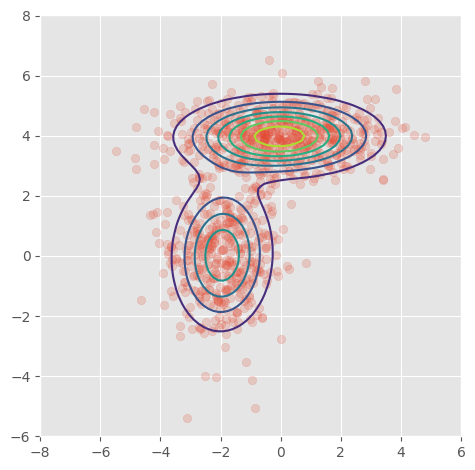

In [8]:
intervals = 101
ys = np.linspace(-8,8,intervals)
X, Y = np.meshgrid(ys, ys)
_ys = np.vstack([X.ravel(), Y.ravel()]).T

z = np.zeros(len(_ys))
for pi, mu, sigma in zip(pis1, mus1, sigmas1):
    z += pi*mvn(mu, sigma).pdf(_ys)
z = z.reshape((intervals, intervals))

ax = plt.subplot(111)
plt.scatter(xs[:,0], xs[:,1], alpha=0.2)
plt.contour(X, Y, z, N=10)
plt.axis([-8,6,-6,8])
ax.axes.set_aspect('equal')
plt.tight_layout()

/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_11978/1942518152.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(range(len(EM_values)), EM_values, '-o', label='EM', color='gold', linestyle='dashed', linewidth=2)


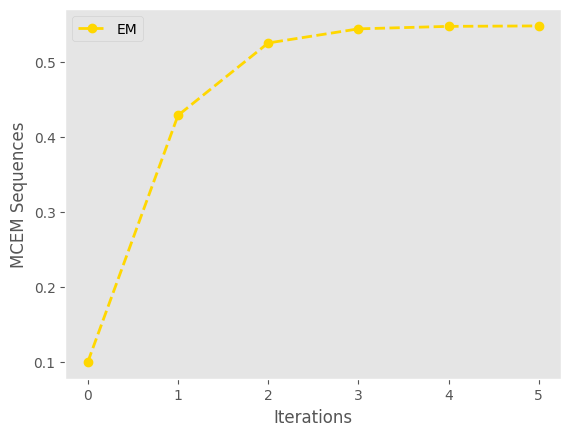

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define the initial values
x = np.array([58, 12, 9, 13])
n = np.sum(x)
start = EM = cur = diff = 0.1

# Initialize lists to store EM values and MCEM sequences
EM_values = [start]
M = 10 ** 2
num_iterations = 250  # Define the number of iterations
MCEM = np.full((500, num_iterations + 1), start)  # Corrected array dimensions

# Define a function to calculate the EM value
def calculate_EM(cur, x):
    return ((cur * x[0] / (2 + cur)) + x[3]) / ((cur * x[0] / (2 + cur)) + x[1] + x[2] + x[3])

# EM algorithm
while diff > 0.001:  # Stopping rule
    EM_new = calculate_EM(cur, x)
    EM_values.append(EM_new)
    diff = np.abs(cur - EM_values[-1])
    cur = EM_values[-1]

# Monte Carlo EM
for i in range(1, num_iterations + 1):  # Loop over the specified number of iterations
    MCEM[:, i] = 1 / (1 + (x[1] + x[2]) / (x[3] + np.random.binomial(M * x[0], 1 / (1 + 2 / MCEM[:, i - 1]), 500) / M))

# Plot EM values and shaded region
plt.plot(range(len(EM_values)), EM_values, '-o', label='EM', color='gold', linestyle='dashed', linewidth=2)
upper_bound = np.max(MCEM, axis=0)
lower_bound = np.min(MCEM, axis=0)
plt.xlabel('Iterations')
plt.ylabel('MCEM Sequences')
plt.legend()
plt.grid()
plt.show()


/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_11978/487944923.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(range(len(EM_values)), EM_values, '-o', label='EM', color='gold', linestyle='dashed', linewidth=2)


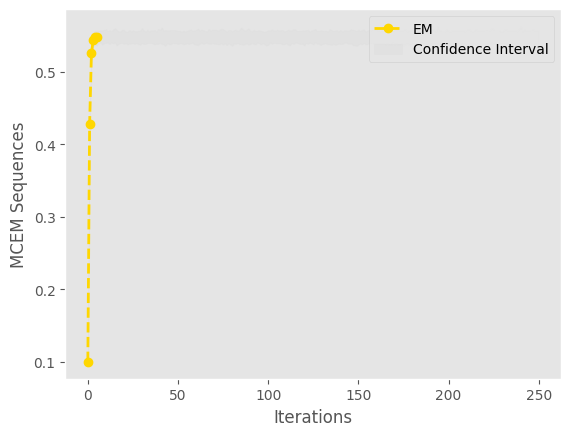

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define the initial values
x = np.array([58, 12, 9, 13])
n = np.sum(x)
start = EM = cur = diff = 0.1

# Initialize lists to store EM values and MCEM sequences
EM_values = [start]
M = 10 ** 2
num_iterations = 250  # Define the number of iterations
MCEM = np.full((500, num_iterations + 1), start)  # Corrected array dimensions

# Define a function to calculate the EM value
def calculate_EM(cur, x):
    return ((cur * x[0] / (2 + cur)) + x[3]) / ((cur * x[0] / (2 + cur)) + x[1] + x[2] + x[3])

# EM algorithm
while diff > 0.001:  # Stopping rule
    EM_new = calculate_EM(cur, x)
    EM_values.append(EM_new)
    diff = np.abs(cur - EM_values[-1])
    cur = EM_values[-1]

# Monte Carlo EM
for i in range(1, num_iterations + 1):  # Loop over the specified number of iterations
    MCEM[:, i] = 1 / (1 + (x[1] + x[2]) / (x[3] + np.random.binomial(M * x[0], 1 / (1 + 2 / MCEM[:, i - 1]), 500) / M))

# Plot EM values and shaded region
plt.plot(range(len(EM_values)), EM_values, '-o', label='EM', color='gold', linestyle='dashed', linewidth=2)
upper_bound = np.max(MCEM, axis=0)
lower_bound = np.min(MCEM, axis=0)
plt.fill_between(range(num_iterations + 1), lower_bound, upper_bound, color=(0.87, 0.87, 0.87), alpha=0.5, label='Confidence Interval')
plt.xlabel('Iterations')
plt.ylabel('MCEM Sequences')
plt.legend()
plt.grid()
plt.show()
